In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

repo_url = (
    "https://huggingface.co/datasets/"
    "cObliUvA/llm-guided-modelling-results/resolve/main"
)

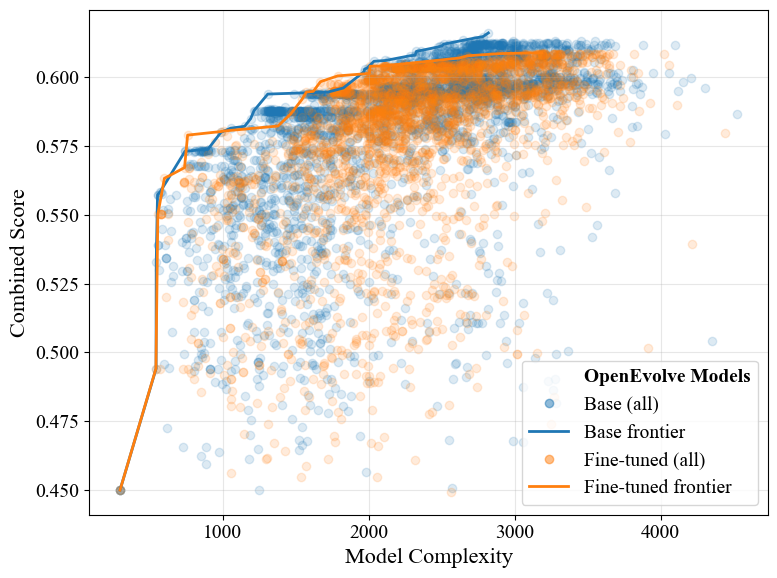

In [3]:
df_base = pd.read_csv(f"{repo_url}/OpenEvolveLogs/OpenEvolveLogs_base.csv")
df_merged = pd.read_csv(f"{repo_url}/OpenEvolveLogs/OpenEvolveLogs_merged.csv")

df_base = df_base[df_base["combined_score"] > 0.449]
df_merged = df_merged[df_merged["combined_score"] > 0.449]

def pareto_frontier(df):
    df = df.sort_values(["combined_score", "model_complexity"], ascending=[False, True])

    frontier = []
    best_complexity = float("inf")

    for _, row in df.iterrows():
        if row["model_complexity"] < best_complexity:
            frontier.append(row)
            best_complexity = row["model_complexity"]

    return pd.DataFrame(frontier)

base_pareto = pareto_frontier(df_base)
merged_pareto = pareto_frontier(df_merged)

plt.figure(figsize=(8, 6))
plt.rcParams.update({
    "font.size": 14,       # default text
    "axes.labelsize": 16,  # axis labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})


base_color = "tab:blue"
merged_color = "tab:orange"

# ---- BASE ----
plt.scatter(
    df_base["model_complexity"],
    df_base["combined_score"],
    alpha=0.15,
    color=base_color,
)

plt.plot(
    base_pareto["model_complexity"],
    base_pareto["combined_score"],
    color=base_color,
    linewidth=2,
)

# ---- MERGED ----
plt.scatter(
    df_merged["model_complexity"],
    df_merged["combined_score"],
    alpha=0.15,
    color=merged_color,
)

plt.plot(
    merged_pareto["model_complexity"],
    merged_pareto["combined_score"],
    color=merged_color,
    linewidth=2,
)

# ---- CUSTOM LEGEND ----
legend_handles = [
    Line2D([], [], linestyle="none", label="OpenEvolve Models"),

    Line2D(
        [], [], marker="o", linestyle="none",
        color=base_color, alpha=0.5,
        label="Base (all)"
    ),
    Line2D(
        [], [], color=base_color, linewidth=2,
        label="Base frontier"
    ),

    Line2D(
        [], [], marker="o", linestyle="none",
        color=merged_color, alpha=0.5,
        label="Fine-tuned (all)"
    ),
    Line2D(
        [], [], color=merged_color, linewidth=2,
        label="Fine-tuned frontier"
    ),
]

legend = plt.legend(handles=legend_handles)
legend.get_texts()[0].set_weight("bold")

plt.xlabel("Model Complexity")
plt.ylabel("Combined Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../Images/OpenEvolveParetoFrontier.png",
    transparent=True,
    bbox_inches="tight",
    dpi=300
)
plt.show()

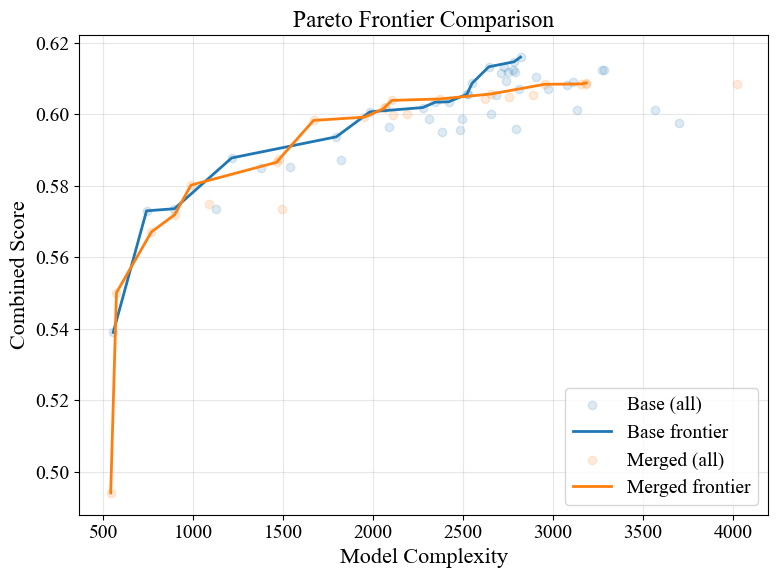

In [4]:
df_base = pd.read_csv(f"{repo_url}/OpenEvolveLogs/OpenEvolveLogs_BestBasePrograms.csv")
df_merged = pd.read_csv(f"{repo_url}/OpenEvolveLogs/OpenEvolveLogs_BestFineTunedPrograms.csv")

df_base = df_base[df_base["combined_score"] > 0.449]
df_merged = df_merged[df_merged["combined_score"] > 0.449]

base_pareto = pareto_frontier(df_base)
merged_pareto = pareto_frontier(df_merged)

# -------------------------
# Selection function
# -------------------------
def select_at_complexity(df, targets=(1000, 1500, 2000), margin=105):
    """
    For each target complexity:
    - filter models within [t - margin, t + margin]
    - sort by nll descending
    - pick first match
    """

    df = df.copy()
    df["model_complexity"] = df["model_complexity"].astype(float)
    df["nll"] = df["nll"].astype(float)

    results = []

    for t in targets:
        lower = t - margin
        upper = t + margin

        subset = df[
            (df["model_complexity"] >= lower) &
            (df["model_complexity"] <= upper)
        ]

        if subset.empty:
            continue  # or handle fallback if needed

        best_row = subset.sort_values("nll", ascending=True).iloc[0].copy()
        best_row["target_complexity"] = t

        results.append(best_row)

    return pd.DataFrame(results)


# -------------------------
# Apply to both datasets
# -------------------------
base_selected = select_at_complexity(df_base)
merged_selected = select_at_complexity(df_merged)

# -------------------------
# Combine results
# -------------------------
final_selection = pd.concat(
    [
        base_selected.assign(dataset="base"),
        merged_selected.assign(dataset="merged")
    ],
    ignore_index=True
)

# Optional: clean display order
final_selection = final_selection[
    [
        "dataset",
        "target_complexity",
        "iteration",
        "program_id",
        "model_complexity",
        "nll",
        "combined_score",
        "runtime",
        "runs_successfully"
    ]
].sort_values(["dataset", "target_complexity"])

plt.figure(figsize=(8, 6))
plt.rcParams.update({
    "font.size": 14,       # default text
    "axes.labelsize": 16,  # axis labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})

base_color = "tab:blue"
merged_color = "tab:orange"

# ---- BASE ----
plt.scatter(
    df_base["model_complexity"],
    df_base["combined_score"],
    alpha=0.15,
    color=base_color,
    label="Base (all)"
)

plt.plot(
    base_pareto["model_complexity"],
    base_pareto["combined_score"],
    color=base_color,
    linewidth=2,
    label="Base frontier"
)

# ---- MERGED ----
plt.scatter(
    df_merged["model_complexity"],
    df_merged["combined_score"],
    alpha=0.15,
    color=merged_color,
    label="Merged (all)"
)

plt.plot(
    merged_pareto["model_complexity"],
    merged_pareto["combined_score"],
    color=merged_color,
    linewidth=2,
    label="Merged frontier"
)

plt.xlabel("Model Complexity")
plt.ylabel("Combined Score")
plt.title("Pareto Frontier Comparison")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../Images/OpenEvolveBestParetoFrontier.png",
    transparent=True,
    bbox_inches="tight",
    dpi=300
)
plt.show()


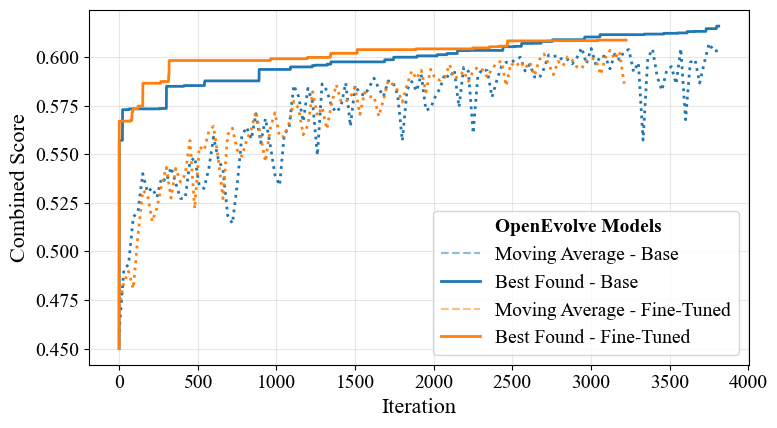

In [5]:
df_base = pd.read_csv(f"{repo_url}/OpenEvolveLogs/OpenEvolveLogs_base.csv")
df_merged = pd.read_csv(f"{repo_url}/OpenEvolveLogs/OpenEvolveLogs_merged.csv")

def prepare_loss_df(df):
    df = df.copy().sort_values("iteration")

    df["best_so_far"] = df["combined_score"].cummax()

    bucket_size = 30
    df["iter_bucket"] = (df["iteration"] // bucket_size) * bucket_size
    mean_curve = df.groupby("iter_bucket")["combined_score"].mean().reset_index()

    return df, mean_curve

base_df, base_mean = prepare_loss_df(df_base)
merged_df, merged_mean = prepare_loss_df(df_merged)
plt.figure(figsize=(8, 4.5))
plt.rcParams.update({
    "font.size": 14,       # default text
    "axes.labelsize": 16,  # axis labels
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "font.family": "serif",
    "font.serif": ["Times New Roman"]
})

# COLORS (fixed mapping)
base_color = "tab:blue"
merged_color = "tab:orange"

# ---- BASE ----
plt.plot(
    base_df["iteration"],
    base_df["best_so_far"],
    color=base_color,
    linewidth=2,
)

plt.plot(
    base_mean["iter_bucket"],
    base_mean["combined_score"],
    color=base_color,
    linestyle="dotted",
    linewidth=2,
)

# ---- MERGED ----
plt.plot(
    merged_df["iteration"],
    merged_df["best_so_far"],
    color=merged_color,
    linewidth=2,
)

plt.plot(
    merged_mean["iter_bucket"],
    merged_mean["combined_score"],
    color=merged_color,
    linestyle="dotted",
    linewidth=2,
)

# ---- CUSTOM LEGEND ----
legend_handles = [
    Line2D([], [], linestyle="none", label="OpenEvolve Models"),

    Line2D(
        [], [], linestyle="--",
        color=base_color, alpha=0.5,
        label="Moving Average - Base"
    ),
    Line2D(
        [], [], color=base_color, linewidth=2,
        label="Best Found - Base"
    ),

    Line2D(
        [], [], linestyle="--",
        color=merged_color, alpha=0.5,
        label="Moving Average - Fine-Tuned"

    ),
    Line2D(
        [], [], color=merged_color, linewidth=2,
        label="Best Found - Fine-Tuned"
    ),
]

legend = plt.legend(handles=legend_handles)
legend.get_texts()[0].set_weight("bold")
# plt.xlim(-50, 3200)
plt.xlabel("Iteration")
plt.ylabel("Combined Score")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(
    "../Images/OpenEvolveScoreCurve.png",
    transparent=True,
    bbox_inches="tight",
    dpi=300
)
plt.show()